# ML -Week 7
## Tasks

* Read and understand the papers
  * “RNA-seq for blood-based pan-cancer diagnostics” by L. Lieben (2015) Nature Reviews Genetics (16)
  (https://www.nature.com/articles/nrg4048)
  * RNA-Seq of Tumor-Educated Platelets Enables Blood-Based Pan-Cancer, Multiclass, and Molecular
  Pathway Cancer Diagnostics by Best et al. (2015) Cancer Cell (https://www.cell.com/cancercell/fulltext/S1535-6108(15)00349-9)
  * “Identifying and analyzing different cancer subtypes using RNA-seq data of blood platelets” by Zhang et
  al. (2017) Oncotarget 8 (50) (https://www.oncotarget.com/article/20903/text/)
* Get familiar with the data and the setting
  * NCBI GEO Data: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE68086
(use the supplementary file “GSE68086_TEP_data_matrix.txt“ file; HD=healthy donor)
* Develop your own Machine Learning method for classification
  * Develop (train) at least one ML classifier (NOT SVM) that can be used to classify healthy vs cancer
  samples. To avoid statistical errors, make sure the all groups have equal size.
  * OPTIONAL: develop a classifier for the multi-class setting.
* Evaluate and interpret the result
  * Evaluate your model using a confusion matrix including the accuracy and a ROC curve (including the
  AUC value) for training AND validation set. (See Figure 1 F,G,H in the Best paper for an example.)
  * Compare the performance of your model to the SVM model from the Best paper and the SVM model
  from the Zhang paper. (You might think, this is not possible. Then: think again)
  * Perform a feature importance analysis and compare your 18 most important features to the top 18
  features from the Zhang paper.

## Publish the deliverables
* Source codes and a quick “How to run” @ GITlab
* Result video @ FU Video Platform
* The following topics / questions must be commented on in your video - you
can of course add more if needed:
  1. Diagnostics:
  How does liquid biopsy work for cancer detection based on platelets?
  Briefly describe the main idea.
  2. Workflow:
  What is the biomedical workflow that needs to be done? Starting from drawing a
  patients blood to having a classifier result. (The GEO DB entry givens a summary.)
  3. Machine Learning:
  Which ML algorithms did you use and how did you implement it?
  4. Results:
  Show and comment on the results that you achieved with your algorithms and
  compare that to the results of the other papers (classifier performance and most
  important features).

# Practical

In [0]:
import seaborn as sns
from itertools import cycle

def print_accuracy_and_classification_report(labels, prediction):
    """Print model accuracy and classification report.
    Args:
        labels (numpy.array): Truth lables
        prediction (numpy.array): Model predictions
    """
    print('Cross validation accuracy:')
    print('\t', metrics.accuracy_score(labels, prediction))
    print('\nCross validation classification report\n')
    print(metrics.classification_report(labels, prediction))

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [0]:
! pip install scikit-plot

In [0]:
import scipy.cluster.hierarchy as sch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
import scikitplot as skplt
import seaborn as sn


from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn import preprocessing
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [0]:
##### IF you use light theme ,dont run this 
plt.rcParams[
    "figure.facecolor"
] = "w"  # force white background on plots when using dark mode in JupyterLab

## Load Data

In [0]:
dataset = pd.read_csv('GSE68086_TEP_data_matrix.csv', index_col=0,header=0)
dataset

,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100,15-Breast-Her2-ampl,16-Breast-WT,21-Breast-WT,33-Breast-Her2-ampl,42-Breast-Her2-ampl,Breast-454,48-Breast-WT,50-Breast-WT,55-Breast-WT,Type-Unknown-6,Breast-564,59-Breast-WT,Breast-590,Breast-60,Breast-603,ALK61-Breast-Her2-unknown,Breast-85,Breast-86,97-Breast-Her2-ampl,Breast-ALK-82,292-Liver-KRAS,316-Liver-KRAS,341-Liver-WT,376-Liver-WT,379-Liver-WT,Chol-410,Chol-442,Chol-460,Chol-611,Chol-ALK-28,VU256-CRC,VU258-CRC,VU272-CRC,VU276-CRC,Type-Unknown-1,329-CRC-KRAS,...,MGH-BrCa-H-11,MGH-BrCa-H-59,MGH-BrCa-H-66,MGH-BrCa-H-68,MGH-BrCa-H-74,MGH-BrCa-H-75,MGH-CRC-368,Vumc-NSCLC-49,Vumc-NSCLC-57,Vumc-NSCLC-59,MGH-BrCa-H31-TR-489,MGH-BrCa-H38-TR467,MGH-BrCa-H63-TR-491,MGH-BrCa-H76-TR469,MGH-BrCa-H81-TR492,MGH-BrCa-H83-TR550,MGH-BrCa-H84-TR551,MGH-BrCa-H89-TR471,MGH-BrCa-H92-TR472,MGH-CRC-412-TR466,MGH-CRC-BRAF4-TR547,MGH-CRC-BRAF5-TR548,MGH-CRC-BRAF6-TR465,MGH-NSCLC-L01-TR458,MGH-NSCLC-L03-TR488,MGH-NSCLC-L07-TR459,MGH-NSCLC-L11-TR477,MGH-NSCLC-L12-TR478,MGH-NSCLC-L18-TR479,MGH-NSCLC-L19-TR461,MGH-NSCLC-L20-TR500,MGH-NSCLC-L22-TR462,MGH-NSCLC-L23-TR524,MGH-NSCLC-L25-TR480,MGH-NSCLC-L39-TR519,MGH-NSCLC-L40-TR520,MGH-NSCLC-L51-TR521,MGH-NSCLC-L58-TR525,MGH-NSCLC-L59-TR522,MGH-NSCLC-L65-TR523
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0,0,0,0,17,0,0,0,0,0,0,0,0,1,2,0,0,0,0,23,0,1,1,0,22,0,8,0,0,0,5,0,5,0,0,0,0,241,0,0,...,2,0,7,0,1,3,0,0,9,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,10,9,0,0,0,0,0,0
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,44,14,16,8,9,0,139,108,55,7,27,0,0,24,12,102,93,1,10,41,4,16,0,9,39,13,19,61,17,18,43,5,29,30,0,1,0,180,8,0,...,21,0,25,11,2,30,17,14,25,40,12,2,25,18,40,6,32,12,4,0,3,24,12,0,31,27,46,42,6,30,2,41,40,15,1,0,13,0,0,10
ENSG00000000457,26,1,14,0,4,20,1,26,24,0,0,1,0,0,0,0,20,0,0,39,0,0,0,7,0,0,0,10,0,9,5,3,3,0,0,0,0,0,13,0,...,11,0,0,5,4,3,2,4,1,24,2,0,10,13,9,0,3,0,0,0,56,0,6,21,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000000460,81,98,18,17,0,20,144,26,97,6,11,7,85,128,28,224,120,21,16,20,21,20,80,27,28,37,25,43,23,11,18,22,35,16,28,0,3,0,37,112,...,38,3,5,6,19,15,5,13,15,37,41,1,17,11,79,16,8,1,36,0,17,1,48,18,23,11,12,3,9,40,23,1,6,22,30,0,1,50,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000273487,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000273488,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000273489,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [0]:
dataset_transposed = dataset.T
dataset_transposed['class'] = dataset_transposed.index
dataset_transposed.reset_index(drop=True, inplace=True)

In [0]:
print(len(dataset_transposed))

285


Check all classes

In [0]:
#corrMatrix = dataset_transposed.corr()

In [0]:
#sn.heatmap(corrMatrix, annot=True)
#plt.show()

In [0]:
dataset_transposed['class'].values

array(['3-Breast-Her2-ampl', '8-Breast-WT', '10-Breast-Her2-ampl',
       'Breast-100', '15-Breast-Her2-ampl', '16-Breast-WT',
       '21-Breast-WT', '33-Breast-Her2-ampl', '42-Breast-Her2-ampl',
       'Breast-454', '48-Breast-WT', '50-Breast-WT', '55-Breast-WT',
       'Type-Unknown-6', 'Breast-564', '59-Breast-WT', 'Breast-590',
       'Breast-60', 'Breast-603', 'ALK61-Breast-Her2-unknown',
       'Breast-85', 'Breast-86', '97-Breast-Her2-ampl', 'Breast-ALK-82',
       '292-Liver-KRAS', '316-Liver-KRAS', '341-Liver-WT', '376-Liver-WT',
       '379-Liver-WT', 'Chol-410', 'Chol-442', 'Chol-460', 'Chol-611',
       'Chol-ALK-28', 'VU256-CRC', 'VU258-CRC', 'VU272-CRC', 'VU276-CRC',
       'Type-Unknown-1', '329-CRC-KRAS', '342-CRC-KRAS', 'Type-Unknown-5',
       '354-CRC-WT', '356-CRC-WT', 'CRC-357', '374-CRC-WT', '378-CRC-WT',
       '420-CRC-WT', '429-CRC-WT', 'CRC-450', '453-CRC-KRAS', 'CRC-459',
       '462-CRC-KRAS', 'CRC-463', '466-CRC-KRAS', '474-CRC-WT', 'CRC-487',
       'CRC-4

## Reassign class 



```

dataset_transposed.replace(['*Breast*','*BrCa*','*NSCLC*','*Lung*','*HD*','*Control*','*Pancr*','*GBM*','*Chol*','*Liver*','*CRC*'],
               ['BrCa','BrCa','NSCLC','NSCLC','HD','HD','PAAD','GBM','HBC','HBC','CRC'], regex=True)
```





In [0]:
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "BrCa" if  "Breast" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "BrCa" if  "BrCa" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "NSCLC" if  "NSCLC" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "NSCLC" if  "Lung" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "HD" if  "HD" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "HD" if  "Control" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "PAAD" if  "Panc" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "GBM" if  "GBM" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "HBC" if  "Chol" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "HBC" if  "Liver" in x else x)
dataset_transposed['class'] = dataset_transposed['class'].apply(lambda x: "CRC" if  "CRC" in x else x)

In [0]:
dataset_transposed['class'].values

array(['BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa',
       'BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa', 'Type-Unknown-6', 'BrCa',
       'BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa', 'BrCa',
       'BrCa', 'HBC', 'HBC', 'HBC', 'HBC', 'HBC', 'HBC', 'HBC', 'HBC',
       'HBC', 'HBC', 'CRC', 'CRC', 'CRC', 'CRC', 'Type-Unknown-1', 'CRC',
       'CRC', 'Type-Unknown-5', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC',
       'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC',
       'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC',
       'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'CRC', 'GBM', 'GBM', 'GBM',
       'GBM', 'GBM', 'GBM', 'VU383Platelet-hiseq', 'GBM',
       'VU394Platelet-hiseq', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM',
       'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM',
       'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM',
       'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'GBM', 'HD', 'HD', 'HD',
       'HD',

In [0]:
print(len(dataset_transposed))

285


Remove Unknown Type



In [0]:
 dataset_transposed = dataset_transposed[~dataset_transposed['class'].str.contains("Type-Unknown")]
dataset_transposed = dataset_transposed[~dataset_transposed['class'].str.contains("Platelet-hiseq")]
 print(" Remaning: ",len(dataset_transposed))

 Remaning:  278


Assign health_status

In [0]:
 dataset_transposed['health_status'] = dataset_transposed['class'].apply(lambda x: "healthy" if  "HD" in x else "cancer")

In [0]:
dataset_transposed['class'].value_counts()

NSCLC    59
HD       54
CRC      44
GBM      38
BrCa     38
PAAD     33
HBC      12
Name: class, dtype: int64

In [0]:
dataset_transposed['health_status'].value_counts()

cancer     224
healthy     54
Name: health_status, dtype: int64

In [0]:
dataset_transposed

index,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,ENSG00000001461,ENSG00000001497,ENSG00000001561,ENSG00000001617,ENSG00000001626,ENSG00000001629,ENSG00000001630,ENSG00000001631,ENSG00000002016,ENSG00000002079,ENSG00000002330,ENSG00000002549,ENSG00000002586,ENSG00000002587,ENSG00000002726,ENSG00000002745,ENSG00000002746,ENSG00000002822,ENSG00000002834,ENSG00000002919,ENSG00000002933,ENSG00000003056,ENSG00000003096,ENSG00000003137,ENSG00000003147,ENSG00000003249,ENSG00000003393,ENSG00000003400,ENSG00000003402,...,ENSG00000273433,ENSG00000273434,ENSG00000273437,ENSG00000273439,ENSG00000273442,ENSG00000273443,ENSG00000273444,ENSG00000273445,ENSG00000273447,ENSG00000273448,ENSG00000273449,ENSG00000273450,ENSG00000273451,ENSG00000273452,ENSG00000273454,ENSG00000273455,ENSG00000273456,ENSG00000273461,ENSG00000273463,ENSG00000273464,ENSG00000273466,ENSG00000273471,ENSG00000273472,ENSG00000273473,ENSG00000273474,ENSG00000273476,ENSG00000273477,ENSG00000273478,ENSG00000273481,ENSG00000273483,ENSG00000273484,ENSG00000273485,ENSG00000273486,ENSG00000273487,ENSG00000273488,ENSG00000273489,ENSG00000273492,ENSG00000273493,class,health_status
0,0,0,44,26,81,171,34,83,0,14,0,96,34,0,0,0,45,0,77,0,0,13,233,4302,0,0,0,0,11,14,4,0,157,10,0,16,0,23,35,251,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,4,0,BrCa,cancer
1,0,0,14,1,98,99,0,107,0,5,1,105,1,5,0,0,20,0,16,0,0,16,111,5220,0,0,0,0,12,45,25,0,181,4,0,37,0,0,12,332,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BrCa,cancer
2,0,0,16,14,18,25,0,62,4,13,0,66,16,0,0,0,32,0,57,0,0,10,122,7160,0,0,0,0,3,10,13,3,268,6,0,9,0,12,3,281,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BrCa,cancer
3,0,0,8,0,17,4,0,19,0,0,9,7,0,0,0,0,10,0,11,0,0,1,10,1622,0,0,0,0,11,5,3,0,54,0,0,0,0,1,4,80,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BrCa,cancer
4,17,0,9,4,0,49,0,40,0,10,5,254,6,4,0,0,20,0,6,0,0,8,46,3871,0,0,0,0,17,26,12,0,120,0,0,3,0,0,7,97,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BrCa,cancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,0,0,0,0,0,105,0,0,0,0,0,0,0,0,0,0,31,0,0,0,0,13,120,3269,0,0,0,0,0,0,0,1,44,0,0,0,0,0,0,73,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NSCLC,cancer
281,0,0,13,0,1,30,0,84,0,25,0,81,0,0,0,0,44,0,20,0,0,47,140,5920,0,0,0,0,8,13,10,7,67,7,0,0,0,3,0,82,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,NSCLC,cancer
282,0,0,0,0,50,53,0,33,21,0,0,0,1,0,0,0,67,0,53,0,0,57,108,9514,0,0,0,0,0,38,0,0,63,10,0,0,0,1,3,311,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NSCLC,cancer
283,0,0,0,0,6,150,0,30,0,0,0,51,0,13,0,0,110,0,0,0,0,37,39,2178,0,0,0,0,42,4,21,0,21,0,0,0,0,0,0,53,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NSCLC,cancer


## Split Data 

In [0]:
columns= dataset_transposed.columns
column_name=  columns[:-2]

In [0]:
######## For 2 classes problem ######
# Get labels for training data
Y = dataset_transposed.health_status.values
# Get training data as numpy array
X = dataset_transposed.drop(['class','health_status'], axis=1).values

# Split the data for cross-validation
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)



######## For multicalss ######
# Get labels for training data
Y_multi = dataset_transposed['class'].values
# Get training data as numpy array
X_multi = dataset_transposed.drop(['class','health_status'], axis=1).values

# Split the data for cross-validation
X_train_multi, X_test_multi, Y_train_multi, Y_test_multi = train_test_split(X_multi, Y_multi, test_size=0.2, random_state=42)

Classification report

health_status
* 'cancer' = 0
* 'healthy' = 1


class <- not doing yet (optional)
* 'BrCa' = 1
* 'NSCLC' = 1
* 'HD' = 1
* 'PAAD' = 1
* 'GBM' = 1
* 'HBC' = 1
* 'CRC' = 1


In [0]:

def predict_classes(probabilities):
    """Predict class labels from probabilities
    Args:
        probabilities (numpy.array): model output for each class
    Returns:
        (numpy.array): Model predicted class labels
    """
    predicted = np.array(
        [list(a).index(max(list(a))) for a in list(probabilities)])
    label_binarizer = preprocessing.LabelBinarizer()

    label_binarizer.fit(range(max(predicted) + 1))
    return label_binarizer.transform(predicted)


from sklearn import preprocessing
leble_encoder = preprocessing.LabelEncoder()
leble_encoder.fit(Y_train)
print(list(leble_encoder.classes_))
Y_one_hot= leble_encoder.transform(Y_train)

Y_test_labels = leble_encoder.transform(Y_test)

['cancer', 'healthy']


In [0]:
print(Y_one_hot)

[0 1 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0]


In [0]:
######## For multicalss ######

from sklearn import preprocessing
enc = preprocessing.MultiLabelBinarizer()
Y_train_multi = enc.fit_transform(Y_train_multi)
print(list(enc.classes_))
Y_train_multi

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

## Random Forests

 trees often perform well on imbalanced datasets because their hierarchical structure allows them to learn signals from both classes.

In [0]:
from sklearn.model_selection import GridSearchCV

# Set parameters for the Random Forest Model
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
# Perform cross validation and pull AUC for various splits
param_grid = { 
    'n_estimators': [10, 100,200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'criterion' :['gini', 'entropy']
}
# Create a based model
rf = RandomForestClassifier()
# Instantiate the grid search model
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, 
                          cv = kfold, verbose = 3 , refit = True)
grid_search.fit(X_train, Y_train) 


Fitting 10 folds for each of 18 candidates, totalling 180 fits
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............
[CV]  criterion=gini, max_features=auto, n_estimators=10, score=0.957, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s remaining:    0.0s


[CV]  criterion=gini, max_features=auto, n_estimators=10, score=0.870, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............
[CV]  criterion=gini, max_features=auto, n_estimators=10, score=0.864, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.3s remaining:    0.0s


[CV]  criterion=gini, max_features=auto, n_estimators=10, score=0.864, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............
[CV]  criterion=gini, max_features=auto, n_estimators=10, score=0.773, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............
[CV]  criterion=gini, max_features=auto, n_estimators=10, score=1.000, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............
[CV]  criterion=gini, max_features=auto, n_estimators=10, score=0.818, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............
[CV]  criterion=gini, max_features=auto, n_estimators=10, score=0.955, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............
[CV]  criterion=gini, max_features=auto, n_estimators=10, score=0.864, total=   0.1s
[CV] criterion=gini, max_features=auto, n_estimators=10 ..............
[CV]  criterion=gini, max_features=auto, n_estimators=10, score=

[Parallel(n_jobs=1)]: Done 180 out of 180 | elapsed:  1.5min finished


GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_sco

In [0]:
# print best parameter after tuning 
print(grid_search.best_params_) 
  
# print how our model looks after hyper-parameter tuning 
print(grid_search.best_estimator_) 

{'criterion': 'entropy', 'max_features': 'auto', 'n_estimators': 100}
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)


### Test set performance

In [0]:
# Determine performance on test set
test_prob = grid_search.best_estimator_.predict_proba(X_test)

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


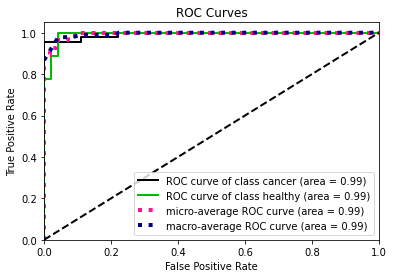

In [0]:
# Plot AUC for test set
skplt.metrics.plot_roc_curve(Y_test, test_prob)

### Evaluate perforamce

Confusion matrix, without normalization
[[47  0]
 [ 2  7]]
Normalized confusion matrix
[[1.         0.        ]
 [0.22222222 0.77777778]]


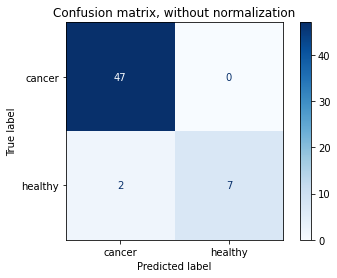

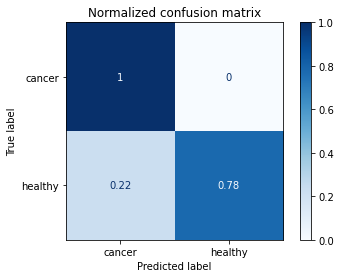

In [0]:
from sklearn.metrics import plot_confusion_matrix

# Plot non-normalized confusion matrix
titles_options = [("Confusion matrix, without normalization", None),
                  ("Normalized confusion matrix", 'true')]
class_names =['cancer','healthy']
for title, normalize in titles_options:
    disp = plot_confusion_matrix(grid_search.best_estimator_, X_test, Y_test,
                                 display_labels=class_names,
                                 cmap=plt.cm.Blues,
                                 normalize=normalize)
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [0]:

# Perform cross validation
probabilities = cross_val_predict(grid_search.best_estimator_, X_train, Y_train, cv=kfold, method='predict_proba')

In [0]:
print_accuracy_and_classification_report(Y_one_hot, predict_classes(probabilities))

Cross validation accuracy:
	 0.8828828828828829

Cross validation classification report

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       177
           1       0.85      0.51      0.64        45

    accuracy                           0.88       222
   macro avg       0.87      0.74      0.78       222
weighted avg       0.88      0.88      0.87       222



/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


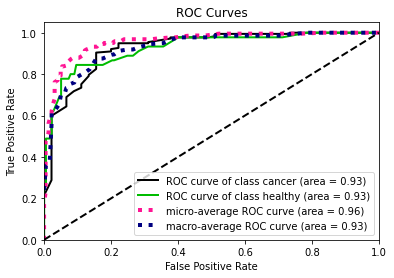

In [0]:
skplt.metrics.plot_roc_curve(Y_train, probabilities)

### Feature importance analysis

In [0]:
 grid_search.best_estimator_.feature_importances_

array([[ 0,  0, 44, ...,  1,  4,  0],
       [ 0,  0, 14, ...,  0,  0,  0],
       [ 0,  0, 16, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0, 10, ...,  0,  0,  0]])

Select first 20 features

In [0]:
sorted_feature_important=sorted(zip(map(lambda x: round(x, 4),  grid_search.best_estimator_.feature_importances_), column_name), 
             reverse=True)

In [0]:
sorted_feature_important[0:19]

[(0.0074, 'ENSG00000143546'),
 (0.0065, 'ENSG00000211788'),
 (0.0065, 'ENSG00000145241'),
 (0.0061, 'ENSG00000186854'),
 (0.0059, 'ENSG00000167286'),
 (0.0052, 'ENSG00000172893'),
 (0.0052, 'ENSG00000149925'),
 (0.0052, 'ENSG00000105369'),
 (0.0049, 'ENSG00000155657'),
 (0.0047, 'ENSG00000204219'),
 (0.0044, 'ENSG00000165244'),
 (0.0044, 'ENSG00000163682'),
 (0.0042, 'ENSG00000106123'),
 (0.004, 'ENSG00000198898'),
 (0.004, 'ENSG00000187800'),
 (0.0039, 'ENSG00000129636'),
 (0.0038, 'ENSG00000143761'),
 (0.0038, 'ENSG00000114626'),
 (0.0037, 'ENSG00000227507')]

dont run this code below , since we have lots of features here (50K)

In [0]:
# Fix which numbers correspond to which variables
feature_importances = pd.DataFrame(grid_search.best_estimator_.feature_importances_ ,index =column_name,
columns=['importance']).sort_values('importance', ascending=False) 
feature_importances

import matplotlib. pyplot as plt
#modelname.feature_importance
x  = feature_importances.importance
col = feature_importances.importance.index

#plot
fig, ax = plt.subplots() 
width = 0.4 # the width of the bars 
ind = np.arange(len(x)) # the x locations for the groups
ax.barh(ind, x, width, color="green")
ax.set_yticks(ind+width/10)
ax.set_yticklabels(col, minor=False)
plt.title("Feature importance in  Classifier")
plt.xlabel("Relative importance")
plt.ylabel("feature") 
plt.figure(figsize=(5,5))
fig.set_size_inches(10, 50, forward=True)

## Hierarchical Clustering


Importing the Dataset

In [0]:
dataset

Using the dendrogram to find the optimal number of clusters

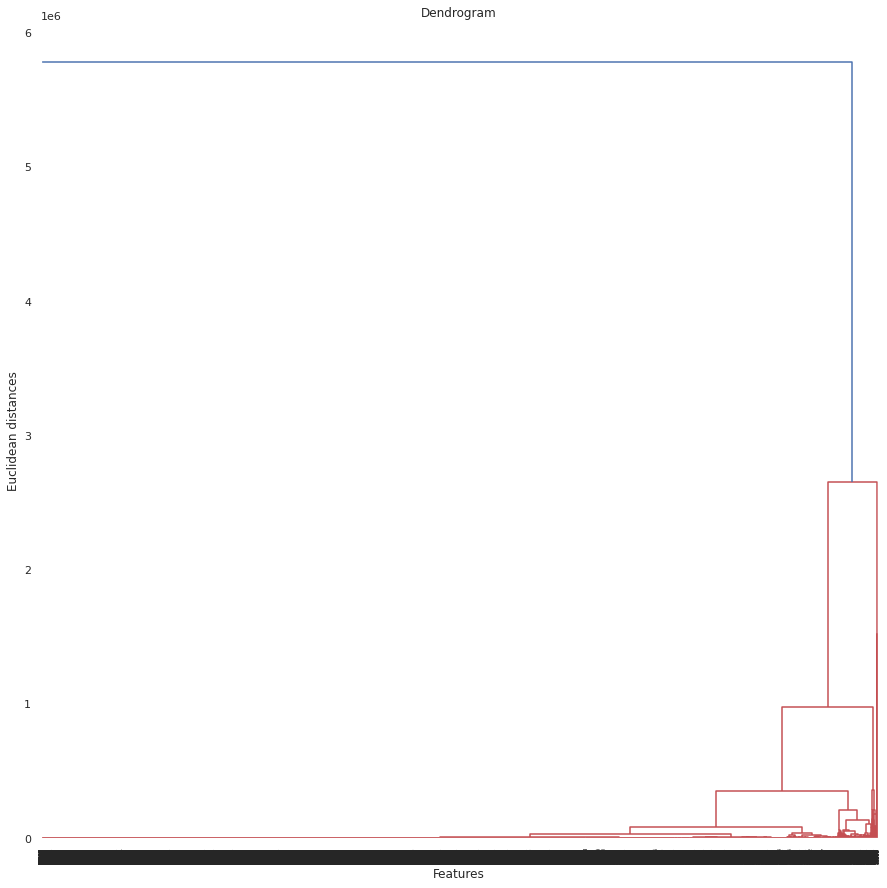

<Figure size 720x720 with 0 Axes>

In [0]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(dataset, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Features')
plt.ylabel('Euclidean distances')
plt.figure(figsize=(10,10))
plt.show()

Training the Hierarchical Clustering model on the dataset

In [0]:
hc = AgglomerativeClustering(n_clusters = 2, affinity = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(dataset)

In [0]:
y_hc[y_hc==1]

array([1, 1, 1])

## K-mean

Using the elbow method to find the optimal number of clusters

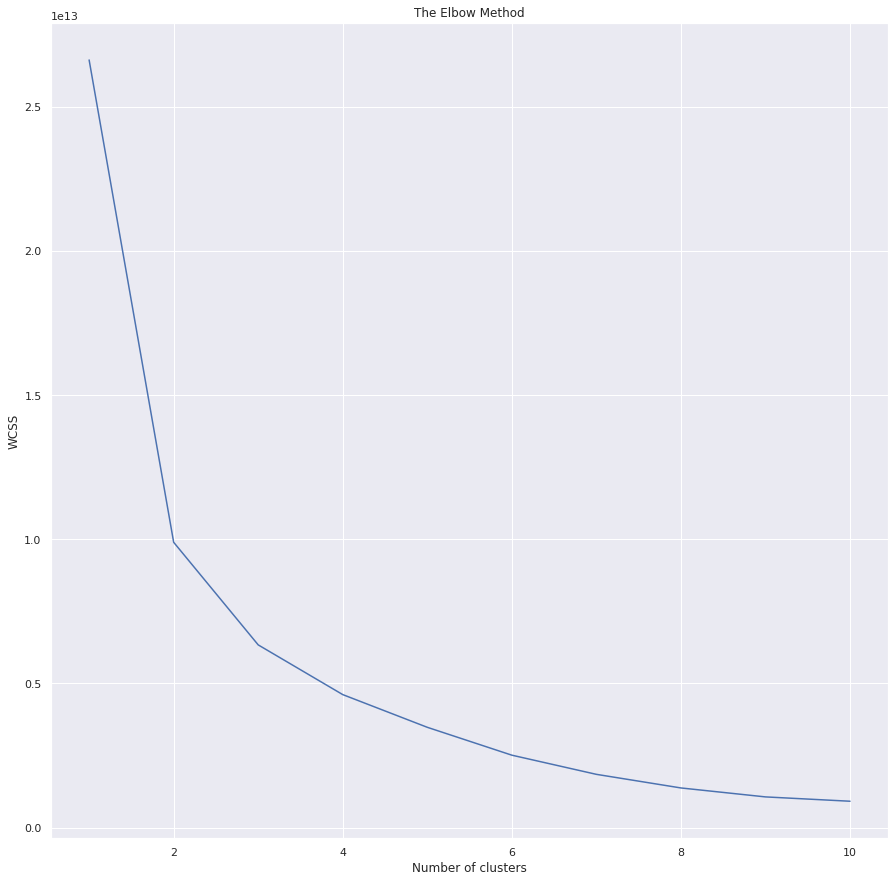

In [0]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(dataset)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [0]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(dataset)

In [0]:
dataset

,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100,15-Breast-Her2-ampl,16-Breast-WT,21-Breast-WT,33-Breast-Her2-ampl,42-Breast-Her2-ampl,Breast-454,48-Breast-WT,50-Breast-WT,55-Breast-WT,Type-Unknown-6,Breast-564,59-Breast-WT,Breast-590,Breast-60,Breast-603,ALK61-Breast-Her2-unknown,Breast-85,Breast-86,97-Breast-Her2-ampl,Breast-ALK-82,292-Liver-KRAS,316-Liver-KRAS,341-Liver-WT,376-Liver-WT,379-Liver-WT,Chol-410,Chol-442,Chol-460,Chol-611,Chol-ALK-28,VU256-CRC,VU258-CRC,VU272-CRC,VU276-CRC,Type-Unknown-1,329-CRC-KRAS,...,MGH-BrCa-H-11,MGH-BrCa-H-59,MGH-BrCa-H-66,MGH-BrCa-H-68,MGH-BrCa-H-74,MGH-BrCa-H-75,MGH-CRC-368,Vumc-NSCLC-49,Vumc-NSCLC-57,Vumc-NSCLC-59,MGH-BrCa-H31-TR-489,MGH-BrCa-H38-TR467,MGH-BrCa-H63-TR-491,MGH-BrCa-H76-TR469,MGH-BrCa-H81-TR492,MGH-BrCa-H83-TR550,MGH-BrCa-H84-TR551,MGH-BrCa-H89-TR471,MGH-BrCa-H92-TR472,MGH-CRC-412-TR466,MGH-CRC-BRAF4-TR547,MGH-CRC-BRAF5-TR548,MGH-CRC-BRAF6-TR465,MGH-NSCLC-L01-TR458,MGH-NSCLC-L03-TR488,MGH-NSCLC-L07-TR459,MGH-NSCLC-L11-TR477,MGH-NSCLC-L12-TR478,MGH-NSCLC-L18-TR479,MGH-NSCLC-L19-TR461,MGH-NSCLC-L20-TR500,MGH-NSCLC-L22-TR462,MGH-NSCLC-L23-TR524,MGH-NSCLC-L25-TR480,MGH-NSCLC-L39-TR519,MGH-NSCLC-L40-TR520,MGH-NSCLC-L51-TR521,MGH-NSCLC-L58-TR525,MGH-NSCLC-L59-TR522,MGH-NSCLC-L65-TR523
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0,0,0,0,17,0,0,0,0,0,0,0,0,1,2,0,0,0,0,23,0,1,1,0,22,0,8,0,0,0,5,0,5,0,0,0,0,241,0,0,...,2,0,7,0,1,3,0,0,9,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,10,9,0,0,0,0,0,0
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,44,14,16,8,9,0,139,108,55,7,27,0,0,24,12,102,93,1,10,41,4,16,0,9,39,13,19,61,17,18,43,5,29,30,0,1,0,180,8,0,...,21,0,25,11,2,30,17,14,25,40,12,2,25,18,40,6,32,12,4,0,3,24,12,0,31,27,46,42,6,30,2,41,40,15,1,0,13,0,0,10
ENSG00000000457,26,1,14,0,4,20,1,26,24,0,0,1,0,0,0,0,20,0,0,39,0,0,0,7,0,0,0,10,0,9,5,3,3,0,0,0,0,0,13,0,...,11,0,0,5,4,3,2,4,1,24,2,0,10,13,9,0,3,0,0,0,56,0,6,21,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000000460,81,98,18,17,0,20,144,26,97,6,11,7,85,128,28,224,120,21,16,20,21,20,80,27,28,37,25,43,23,11,18,22,35,16,28,0,3,0,37,112,...,38,3,5,6,19,15,5,13,15,37,41,1,17,11,79,16,8,1,36,0,17,1,48,18,23,11,12,3,9,40,23,1,6,22,30,0,1,50,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000273487,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000273488,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000273489,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [0]:
y_kmeans

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [0]:
from sklearn.manifold import TSNE

tsne = TSNE(verbose=1, perplexity=100, random_state=42)
X_embedded = tsne.fit_transform(dataset)

[t-SNE] Computing 301 nearest neighbors...
[t-SNE] Indexed 28541 samples in 3.276s...
[t-SNE] Computed neighbors for 28541 samples in 351.630s...
[t-SNE] Computed conditional probabilities for sample 1000 / 28541
[t-SNE] Computed conditional probabilities for sample 2000 / 28541
[t-SNE] Computed conditional probabilities for sample 3000 / 28541
[t-SNE] Computed conditional probabilities for sample 4000 / 28541
[t-SNE] Computed conditional probabilities for sample 5000 / 28541
[t-SNE] Computed conditional probabilities for sample 6000 / 28541
[t-SNE] Computed conditional probabilities for sample 7000 / 28541
[t-SNE] Computed conditional probabilities for sample 8000 / 28541
[t-SNE] Computed conditional probabilities for sample 9000 / 28541
[t-SNE] Computed conditional probabilities for sample 10000 / 28541
[t-SNE] Computed conditional probabilities for sample 11000 / 28541
[t-SNE] Computed conditional probabilities for sample 12000 / 28541
[t-SNE] Computed conditional probabilities for 

In [0]:
y_kmeans[y_kmeans==1]

array([1, 1, 1], dtype=int32)

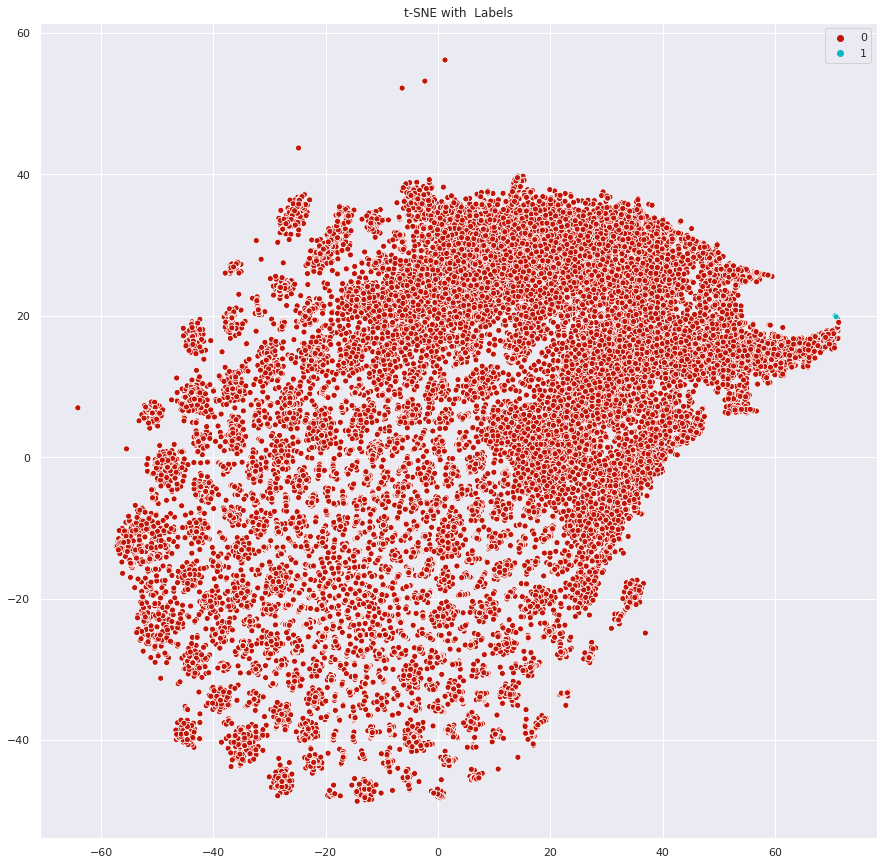

In [0]:
from matplotlib import pyplot as plt
import seaborn as sns

# sns settings
sns.set(rc={'figure.figsize':(15,15)})

# colors
palette = sns.hls_palette(2, l=.4, s=.9)

# plot
sns.scatterplot(X_embedded[:,0], X_embedded[:,1], palette=palette, hue=y_kmeans, legend='full')
plt.title('t-SNE with  Labels')
plt.show()
